In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

C:\Users\Daisy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Load  training data from fraudtrain.csv
df_train = pd.read_csv('fraudtrain.csv')
X_train = df_train.drop(columns=['is_fraud'])
y_train = df_train['is_fraud']

# Load test data from fraudtest.csv
df_test = pd.read_csv('fraudtest.csv')
X_test = df_test.drop(columns=['is_fraud'])
y_test = df_test['is_fraud']

In [3]:
# Print type and shape of each DataFrame and Series
print(f'Type and Shape of df_train: Type={type(df_train)}, Shape={df_train.shape}')
print(f'Type and Shape of X_train: Type={type(X_train)}, Shape={X_train.shape}')
print(f'Type and Shape of y_train: Type={type(y_train)}, Shape={y_train.shape}')
print(f'Type and Shape of df_test: Type={type(df_test)}, Shape={df_test.shape}')

Type and Shape of df_train: Type=<class 'pandas.core.frame.DataFrame'>, Shape=(1296675, 23)
Type and Shape of X_train: Type=<class 'pandas.core.frame.DataFrame'>, Shape=(1296675, 22)
Type and Shape of y_train: Type=<class 'pandas.core.series.Series'>, Shape=(1296675,)
Type and Shape of df_test: Type=<class 'pandas.core.frame.DataFrame'>, Shape=(555719, 23)


In [4]:
X_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459


In [5]:
X_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734


# Feature Engineering
* Distance Calculation

In [6]:
# Define a function to calcuulate distance between cardholder and merchant locations
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the Earth's surface using Haversine formula.
    """
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km

In [7]:
# Calculate distances and create new column
X_train['distance_km'] = haversine(X_train['merch_long'], X_train['merch_lat'], X_train['long'], X_train['lat'])
X_test['distance_km'] = haversine(X_test['merch_long'], X_test['merch_lat'], X_test['long'], X_test['lat'])
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [8]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

* Age calculation

In [9]:
import pandas as pd

# Convert 'dob' and 'trans_date_trans_time' to datetime in training and test sets
X_train['dob'] = pd.to_datetime(X_train['dob'])
X_train['trans_date_trans_time'] = pd.to_datetime(X_train['trans_date_trans_time'])

X_test['dob'] = pd.to_datetime(X_test['dob'])
X_test['trans_date_trans_time'] = pd.to_datetime(X_test['trans_date_trans_time'])

# Calculate age accurately in training set
X_train['age'] = X_train['trans_date_trans_time'].dt.year - X_train['dob'].dt.year
X_train['age'] -= ((X_train['trans_date_trans_time'].dt.month < X_train['dob'].dt.month) |
                    ((X_train['trans_date_trans_time'].dt.month == X_train['dob'].dt.month) &
                     (X_train['trans_date_trans_time'].dt.day < X_train['dob'].dt.day))).astype(int)

# Calculate age accurately in test set
X_test['age'] = X_test['trans_date_trans_time'].dt.year - X_test['dob'].dt.year
X_test['age'] -= ((X_test['trans_date_trans_time'].dt.month < X_test['dob'].dt.month) |
                   ((X_test['trans_date_trans_time'].dt.month == X_test['dob'].dt.month) &
                    (X_test['trans_date_trans_time'].dt.day < X_test['dob'].dt.day))).astype(int)

# Remove the 'dob' column
X_train.drop(columns=['dob'], inplace=True)
X_test.drop(columns=['dob'], inplace=True)

# Display DataFrame information
print("Training DataFrame Info:")
print(X_train.info())

print("\nTest DataFrame Info:")
print(X_test.info())

Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   Unnamed: 0             1296675 non-null  int64         
 1   trans_date_trans_time  1296675 non-null  datetime64[ns]
 2   cc_num                 1296675 non-null  int64         
 3   merchant               1296675 non-null  object        
 4   category               1296675 non-null  object        
 5   amt                    1296675 non-null  float64       
 6   first                  1296675 non-null  object        
 7   last                   1296675 non-null  object        
 8   gender                 1296675 non-null  object        
 9   street                 1296675 non-null  object        
 10  city                   1296675 non-null  object        
 11  state                  1296675 non-null  object        
 12  zip

### Extrace year, month, day, hour, dayofweek then drop trans_date_trans_time

In [10]:
# Convert 'trans_date_trans_time' to datetime in training and test sets
X_train['trans_date_trans_time'] = pd.to_datetime(X_train['trans_date_trans_time'])
X_test['trans_date_trans_time'] = pd.to_datetime(X_test['trans_date_trans_time'])

# Extract date and time features for the training set
X_train['trans_year'] = X_train['trans_date_trans_time'].dt.year
X_train['trans_month'] = X_train['trans_date_trans_time'].dt.month
X_train['trans_day'] = X_train['trans_date_trans_time'].dt.day
X_train['trans_hour'] = X_train['trans_date_trans_time'].dt.hour
X_train['trans_dayofweek'] = X_train['trans_date_trans_time'].dt.dayofweek

# Extract date and time features for the test set
X_test['trans_year'] = X_test['trans_date_trans_time'].dt.year
X_test['trans_month'] = X_test['trans_date_trans_time'].dt.month
X_test['trans_day'] = X_test['trans_date_trans_time'].dt.day
X_test['trans_hour'] = X_test['trans_date_trans_time'].dt.hour
X_test['trans_dayofweek'] = X_test['trans_date_trans_time'].dt.dayofweek

# Drop the 'trans_date_trans_time' column 
X_train.drop(columns=['trans_date_trans_time'], inplace=True)
X_test.drop(columns=['trans_date_trans_time'], inplace=True)

# Display DataFrame information
print("Training DataFrame Info:")
print(X_train.info())

print("\nTest DataFrame Info:")
print(X_test.info())

Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 27 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1296675 non-null  int64  
 1   cc_num           1296675 non-null  int64  
 2   merchant         1296675 non-null  object 
 3   category         1296675 non-null  object 
 4   amt              1296675 non-null  float64
 5   first            1296675 non-null  object 
 6   last             1296675 non-null  object 
 7   gender           1296675 non-null  object 
 8   street           1296675 non-null  object 
 9   city             1296675 non-null  object 
 10  state            1296675 non-null  object 
 11  zip              1296675 non-null  int64  
 12  lat              1296675 non-null  float64
 13  long             1296675 non-null  float64
 14  city_pop         1296675 non-null  int64  
 15  job              1296675 non-null  object

### Drop unneccessary columns

In [11]:
X_train= X_train.drop(['Unnamed: 0','first','last','merch_lat','merch_long','lat','long','street'], axis=1)
X_test= X_test.drop(['Unnamed: 0','first','last','merch_lat','merch_long','lat','long','street'], axis=1)

# Display DataFrame information
print("Training DataFrame Info:")
print(X_train.info())

print("\nTest DataFrame Info:")
print(X_test.info())

Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 19 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   cc_num           1296675 non-null  int64  
 1   merchant         1296675 non-null  object 
 2   category         1296675 non-null  object 
 3   amt              1296675 non-null  float64
 4   gender           1296675 non-null  object 
 5   city             1296675 non-null  object 
 6   state            1296675 non-null  object 
 7   zip              1296675 non-null  int64  
 8   city_pop         1296675 non-null  int64  
 9   job              1296675 non-null  object 
 10  trans_num        1296675 non-null  object 
 11  unix_time        1296675 non-null  int64  
 12  distance_km      1296675 non-null  float64
 13  age              1296675 non-null  int32  
 14  trans_year       1296675 non-null  int32  
 15  trans_month      1296675 non-null  int32 

Divide training data into categorical and numerical subsets

In [12]:
X_train_cat = X_train.select_dtypes(include ='object').copy()
X_train_num = X_train.select_dtypes(include = 'number' ).copy()
X_train_cat.head()

,merchant,category,gender,city,state,job,trans_num
0,"fraud_Rippin, Kub and Mann",misc_net,F,Moravian Falls,NC,"Psychologist, counselling",0b242abb623afc578575680df30655b9
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,F,Orient,WA,Special educational needs teacher,1f76529f8574734946361c461b024d99
2,fraud_Lind-Buckridge,entertainment,M,Malad City,ID,Nature conservation officer,a1a22d70485983eac12b5b88dad1cf95
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,M,Boulder,MT,Patent attorney,6b849c168bdad6f867558c3793159a81
4,fraud_Keeling-Crist,misc_pos,M,Doe Hill,VA,Dance movement psychotherapist,a41d7549acf90789359a9aa5346dcb46


In [13]:
X_train_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   merchant   1296675 non-null  object
 1   category   1296675 non-null  object
 2   gender     1296675 non-null  object
 3   city       1296675 non-null  object
 4   state      1296675 non-null  object
 5   job        1296675 non-null  object
 6   trans_num  1296675 non-null  object
dtypes: object(7)
memory usage: 69.3+ MB


In [14]:
X_train_num.head()

,cc_num,amt,zip,city_pop,unix_time,distance_km,age,trans_year,trans_month,trans_day,trans_hour,trans_dayofweek
0,2703186189652095,4.97,28654,3495,1325376018,78.597568,30,2019,1,1,0,1
1,630423337322,107.23,99160,149,1325376044,30.212176,40,2019,1,1,0,1
2,38859492057661,220.11,83252,4154,1325376051,108.206083,56,2019,1,1,0,1
3,3534093764340240,45.00,59632,1939,1325376076,95.673231,51,2019,1,1,0,1
4,375534208663984,41.96,24433,99,1325376186,77.556744,32,2019,1,1,0,1


In [15]:
X_train_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   cc_num           1296675 non-null  int64  
 1   amt              1296675 non-null  float64
 2   zip              1296675 non-null  int64  
 3   city_pop         1296675 non-null  int64  
 4   unix_time        1296675 non-null  int64  
 5   distance_km      1296675 non-null  float64
 6   age              1296675 non-null  int32  
 7   trans_year       1296675 non-null  int32  
 8   trans_month      1296675 non-null  int32  
 9   trans_day        1296675 non-null  int32  
 10  trans_hour       1296675 non-null  int32  
 11  trans_dayofweek  1296675 non-null  int32  
dtypes: float64(2), int32(6), int64(4)
memory usage: 89.0 MB


## Feature selection using chi2 for categorical columns

In [16]:
from scipy.stats import chi2_contingency

# define an empty dictionary to store chi-squared test results
chi2_check = {}

# loop over each column in the training set to calculate chi-statistic with the target variable
for column in X_train_cat:
    chi, p, dof, ex = chi2_contingency(pd.crosstab(y_train, X_train_cat[column]))
    chi2_check.setdefault('Feature',[]).append(column)
    chi2_check.setdefault('p-value',[]) .append(round(p, 10))

# convert the dictionary to a DF
chi2_result = pd.DataFrame(data = chi2_check)
chi2_result.sort_values(by =['p-value'], ascending = True, ignore_index = True, inplace = True)
print(chi2_result)

     Feature   p-value
0   merchant  0.000000
1   category  0.000000
2     gender  0.000000
3       city  0.000000
4      state  0.000000
5        job  0.000000
6  trans_num  0.499587


## Interpretation:
### Low p-values (close to 0):

Features: merchant, category, gender, city, state, job
Interpretation: These features have very low p-values, indicating that there is a statistically significant association between these features and the target variable. In other words, changes in these features are highly likely to be associated with changes in the target variable.
### Higher p-values (close to 1):

Features: trans_num
Interpretation: These features have higher p-values, suggesting that there is no statistically significant association between these features and the target variable. This means changes in these features are not likely to be associated with changes in the target variable.

### Conclusion : drop trans_num

## Feature selection using ANOVA for numerical columns

In [17]:
from sklearn.feature_selection import f_classif
# since f_class_if does not accept missing values, we will do a very crude imputation of missing values
X_train_num.fillna(X_train_num.mean(), inplace = True)
# Calculate F Statistic and corresponding p values
F_statistic, p_values = f_classif(X_train_num, y_train)
# convert to a DF
ANOVA_F_table = pd.DataFrame(data = {'Numerical_Feature': X_train_num.columns.values, 'F-Score': F_statistic, 'p values': p_values.round(decimals=10)})
ANOVA_F_table.sort_values(by = ['F-Score' ], ascending = False, ignore_index = True, inplace = True)
ANOVA_F_table.head(12)

,Numerical_Feature,F-Score,p values
0,amt,65576.034604,0.000000e+00
1,trans_hour,246.962906,0.000000e+00
2,trans_month,199.707387,0.000000e+00
3,age,194.548569,0.000000e+00
4,unix_time,33.432153,7.400000e-09
5,trans_day,19.195591,1.179950e-05
6,trans_year,11.698273,6.256005e-04
7,zip,6.060474,1.382418e-02
8,city_pop,5.915552,1.500794e-02
9,trans_dayofweek,3.921812,4.766369e-02


## Significant Features:
### amt: 
This feature has the highest F-Score (65576.034604) and a p-value of 0, indicating that it is highly statistically significant and explains a substantial amount of variance in the target variable.
### trans_hour, trans_month, age: 
These features also have very high F-Scores (246.962906, 199.707387, and 194.548569 respectively) and p-values of 0, making them highly significant.
### unix_time, trans_day, trans_year: 
These features have lower F-Scores compared to the top features but still have very low p-values (all below 0.001), indicating they are statistically significant.

## Less Significant Features:

### zip, city_pop, trans_dayofweek: 
These features have moderate F-Scores (6.060474, 5.915552, and 3.921812) and lower p-values (0.0138, 0.0150, and 0.0477 respectively), making them statistically significant but less so than the previously mentioned features.

### cc_num:
This feature has a low F-Score (1.249028) and a relatively high p-value (0.263738), suggesting that it is not statistically significant in explaining the variance in the target variable. However, the p-value is not extremely high, so it could be considered borderline significant.
### distance_km:
This feature has the lowest F-Score (0.210314) and the highest p-value (0.646522), indicating that it is not statistically significant and does not contribute much to explaining the variance in the target variable.
## Interpretation:
The features with lower p-values and higher F-Scores (e.g., amt, trans_hour, trans_month, age) are statistically significant and important for the model.
Features like cc_num are less significant but could still be considered for inclusion, especially if they are borderline significant and have potential relevance to the problem.
distance_km appears to be the least significant feature and might be a candidate for exclusion.







## Time to drop unncessary columns

In [19]:
X_train= X_train.drop(['trans_num','zip','city_pop','trans_dayofweek','cc_num','distance_km'], axis=1)
X_test= X_test.drop(['trans_num','zip','city_pop','trans_dayofweek','cc_num','distance_km'], axis=1)
# Display DataFrame information
print("Training DataFrame Info:")
print(X_train.info())

print("\nTest DataFrame Info:")
print(X_test.info())

Training DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 13 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   merchant     1296675 non-null  object 
 1   category     1296675 non-null  object 
 2   amt          1296675 non-null  float64
 3   gender       1296675 non-null  object 
 4   city         1296675 non-null  object 
 5   state        1296675 non-null  object 
 6   job          1296675 non-null  object 
 7   unix_time    1296675 non-null  int64  
 8   age          1296675 non-null  int32  
 9   trans_year   1296675 non-null  int32  
 10  trans_month  1296675 non-null  int32  
 11  trans_day    1296675 non-null  int32  
 12  trans_hour   1296675 non-null  int32  
dtypes: float64(1), int32(5), int64(1), object(6)
memory usage: 103.9+ MB
None

Test DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 13 

### Encoding
* Numerical Feature

In [20]:
# installing features enngine
!pip install feature_engine

In [21]:
# Selecting numerical columns from X_train
num_cols_train = X_train.select_dtypes(include=np.number).columns

# Selecting numerical columns from X_test
num_cols_test = X_test.select_dtypes(include=np.number).columns

print("Numerical columns in X_train:")
print(num_cols_train)

print("\nNumerical columns in X_test:")
print(num_cols_test)

Numerical columns in X_train:
Index(['amt', 'unix_time', 'age', 'trans_year', 'trans_month', 'trans_day',
       'trans_hour'],
      dtype='object')

Numerical columns in X_test:
Index(['amt', 'unix_time', 'age', 'trans_year', 'trans_month', 'trans_day',
       'trans_hour'],
      dtype='object')


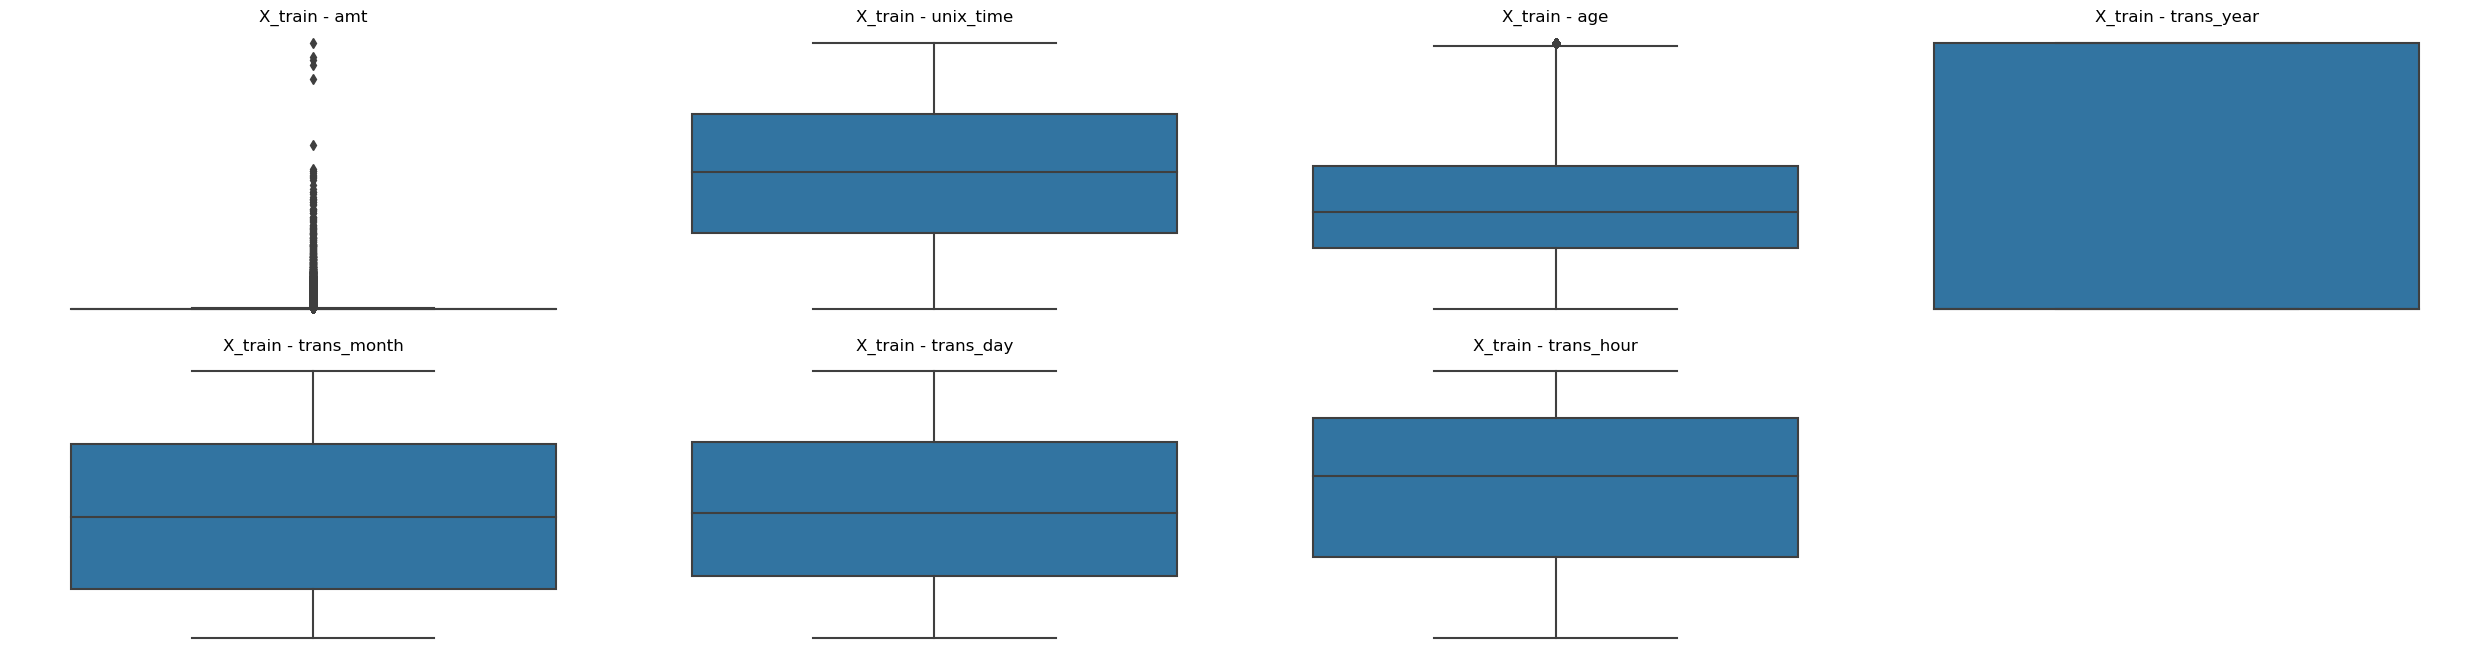

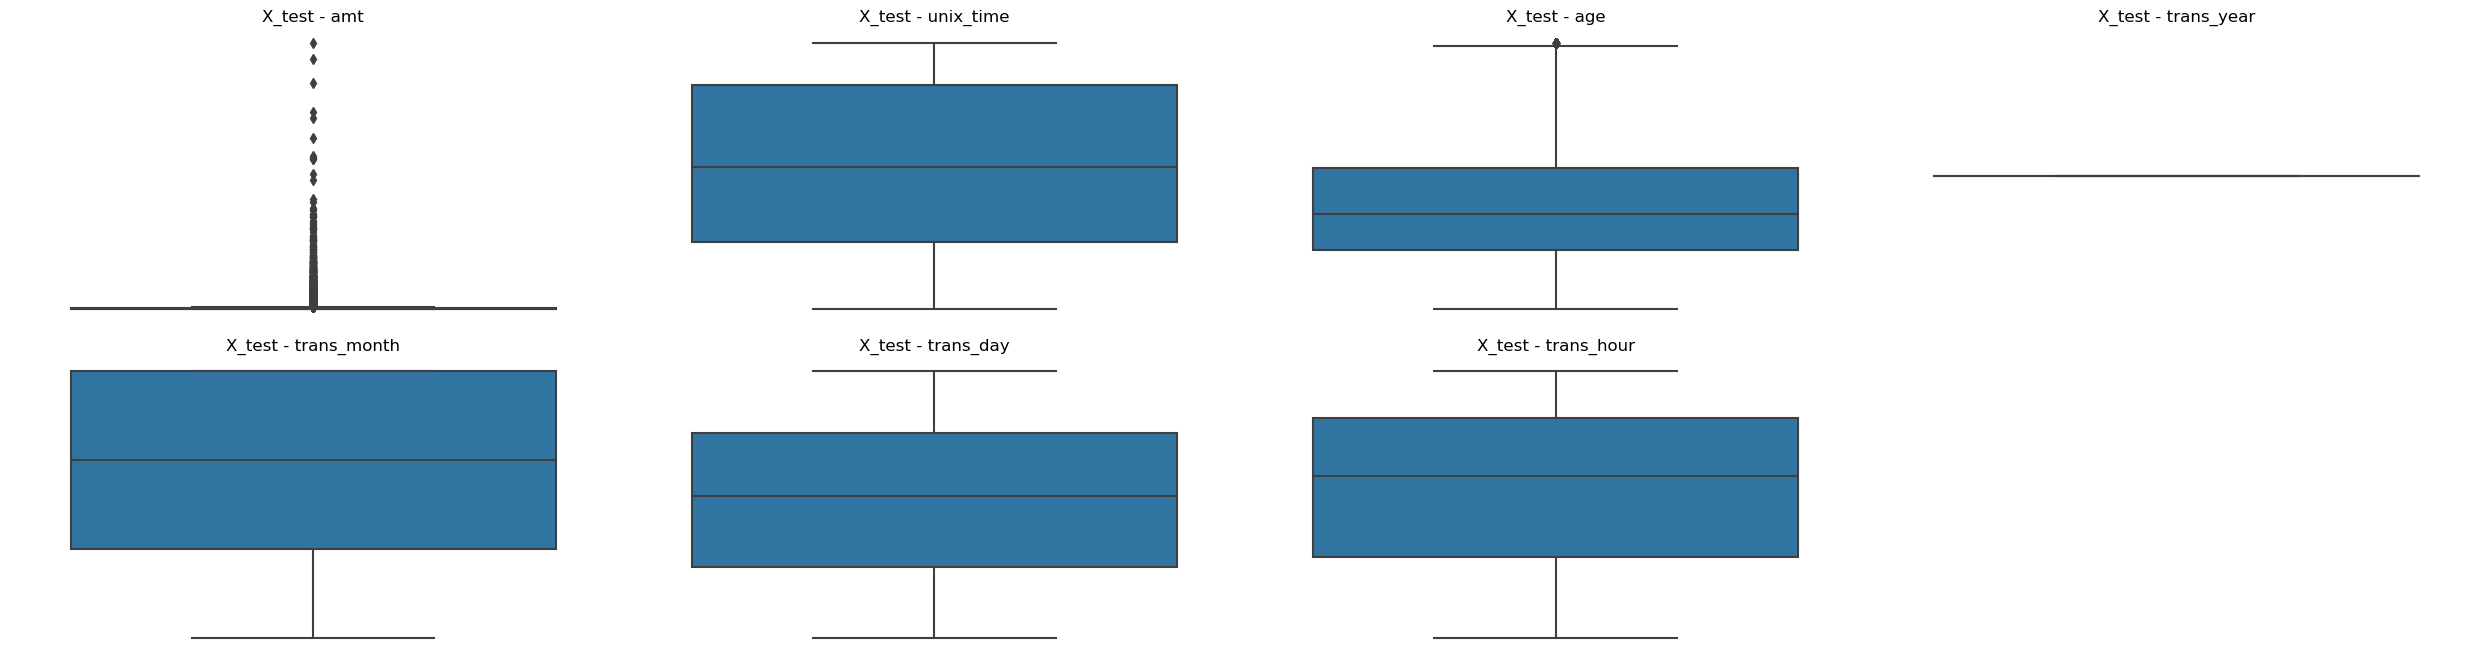

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Checking for outliers in X_train
plt.figure(figsize=[25, 10])
num_cols_train = X_train.select_dtypes(include=np.number).columns

for ind, col_name in enumerate(num_cols_train):
    plt.subplot(3, 4, ind + 1)
    sns.boxplot(X_train[col_name])
    plt.title(f'X_train - {col_name}')
    plt.axis(False)

plt.tight_layout()
plt.show()

# Checking for outliers in X_test
plt.figure(figsize=[25, 10])
num_cols_test = X_test.select_dtypes(include=np.number).columns

for ind, col_name in enumerate(num_cols_test):
    plt.subplot(3, 4, ind + 1)
    sns.boxplot(X_test[col_name])
    plt.title(f'X_test - {col_name}')
    plt.axis(False)

plt.tight_layout()
plt.show()


### amt and age has outliers

In [23]:
from feature_engine.outliers import Winsorizer

# Define the columns with outliers to be capped
outliers = ['amt', 'age']

# Initialize the Winsorizer with IQR method and fold
capper_iqr = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=outliers)

# Fit the Winsorizer on the training data
capper_iqr.fit(X_train)

# Transform both training and testing data
X_train = capper_iqr.transform(X_train)
X_test = capper_iqr.transform(X_test)

# Optionally, print the shapes to verify the transformation
print(f"Transformed X_train shape: {X_train.shape}")
print(f"Transformed X_test shape: {X_test.shape}")

Transformed X_train shape: (1296675, 13)
Transformed X_test shape: (555719, 13)


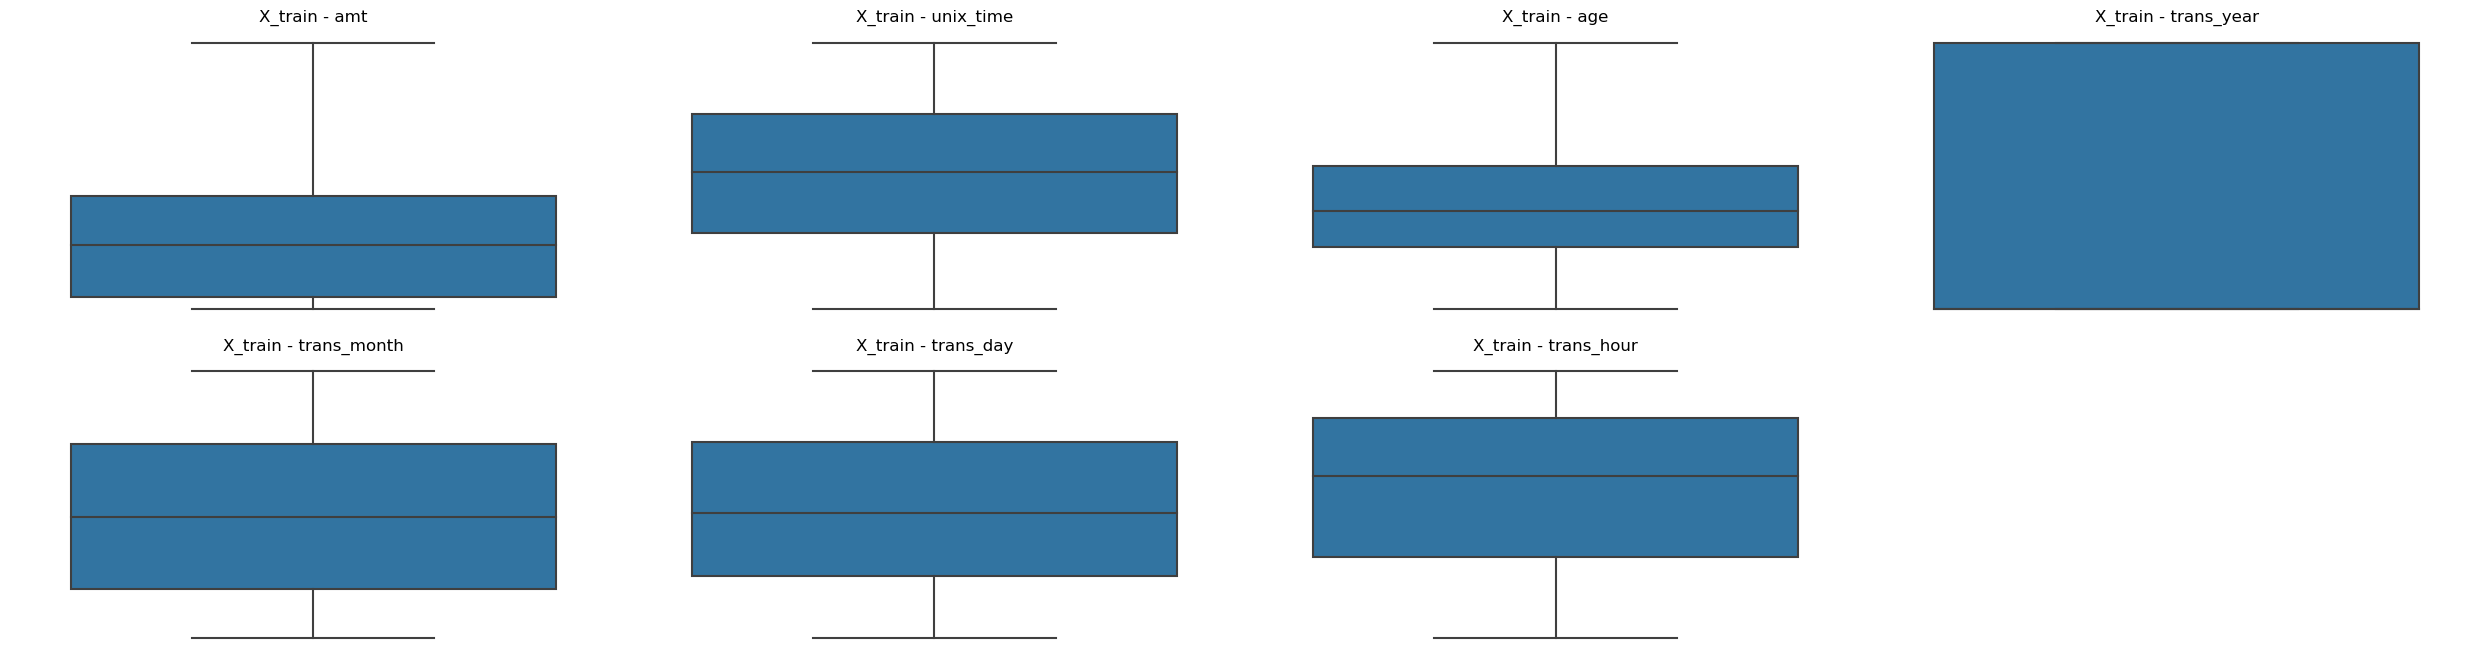

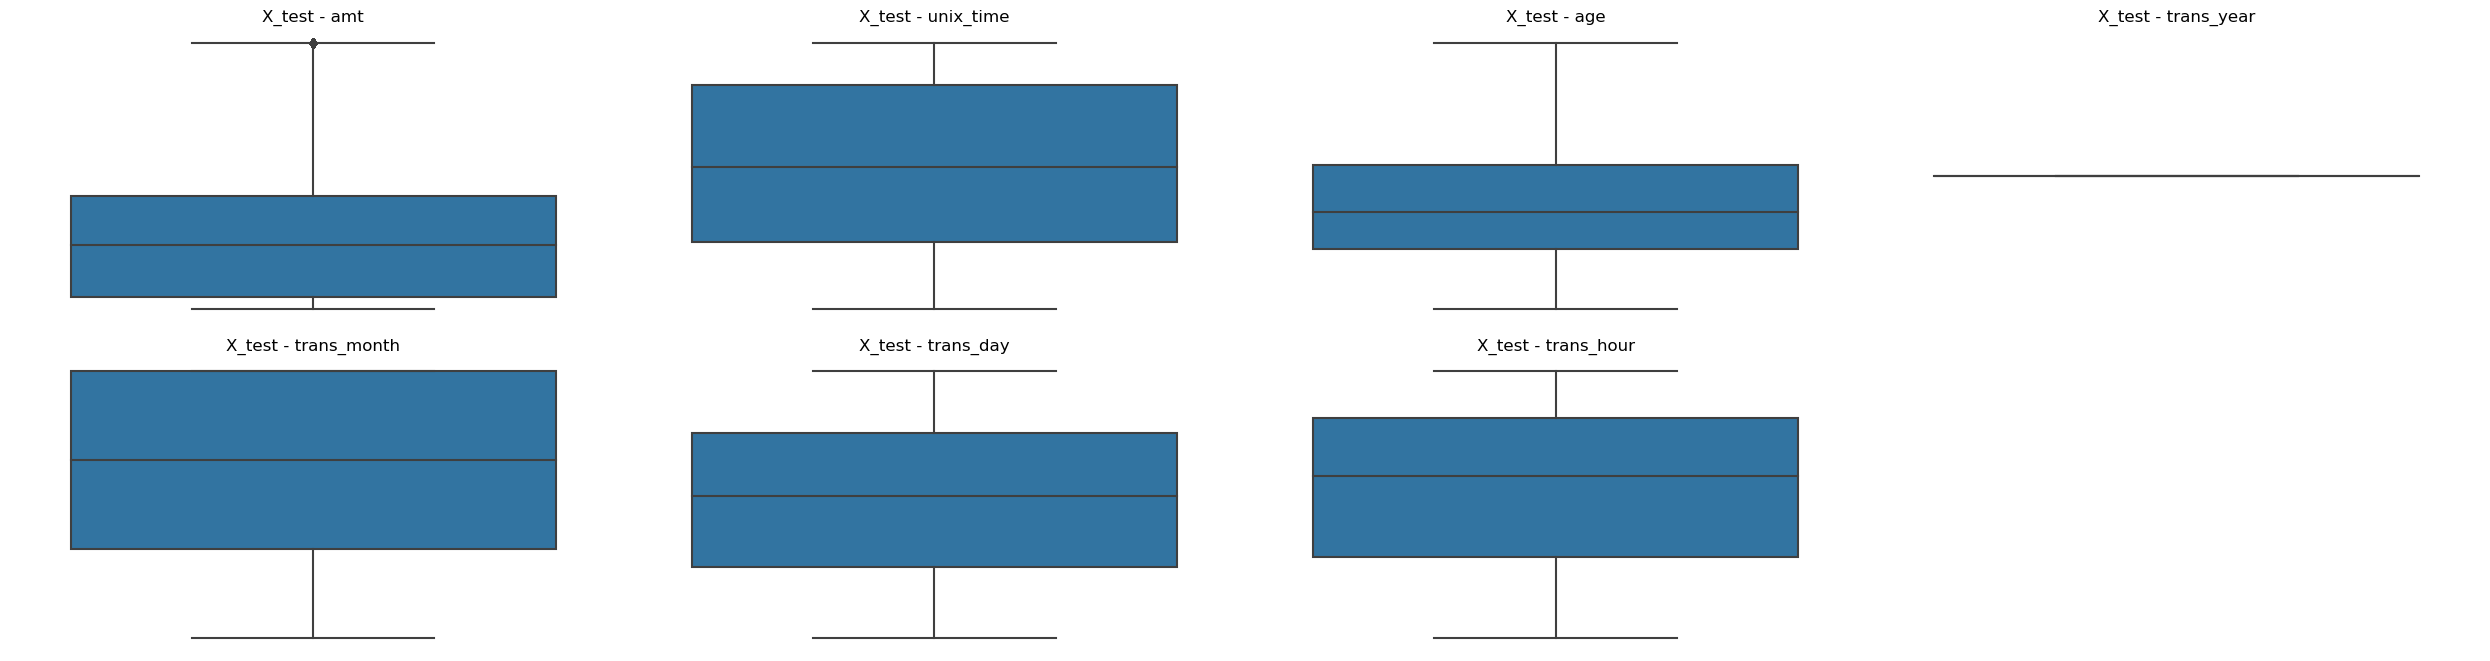

In [24]:
# Checking for outliers in X_train
plt.figure(figsize=[25, 10])
num_cols_train = X_train.select_dtypes(include=np.number).columns

for ind, col_name in enumerate(num_cols_train):
    plt.subplot(3, 4, ind + 1)
    sns.boxplot(X_train[col_name])
    plt.title(f'X_train - {col_name}')
    plt.axis(False)

plt.tight_layout()
plt.show()

# Checking for outliers in X_test
plt.figure(figsize=[25, 10])
num_cols_test = X_test.select_dtypes(include=np.number).columns

for ind, col_name in enumerate(num_cols_test):
    plt.subplot(3, 4, ind + 1)
    sns.boxplot(X_test[col_name])
    plt.title(f'X_test - {col_name}')
    plt.axis(False)

plt.tight_layout()
plt.show()

In [25]:
# Define the mapping for 'gender' column
gender_mapping = {'M': 0, 'F': 1}

# Apply mapping to 'gender' column in X_train
X_train['gender'] = X_train['gender'].map(gender_mapping)

# Apply mapping to 'gender' column in X_test
X_test['gender'] = X_test['gender'].map(gender_mapping)

# Display the first few rows of the modified X_train and X_test
print("X_train head:")
print(X_train.head())

print("X_test head:")
print(X_test.head())

X_train head:
                             merchant       category      amt  gender  \
0          fraud_Rippin, Kub and Mann       misc_net    4.970       1   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.230       1   
2                fraud_Lind-Buckridge  entertainment  193.375       0   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.000       0   
4                 fraud_Keeling-Crist       misc_pos   41.960       0   

             city state                                job   unix_time   age  \
0  Moravian Falls    NC          Psychologist, counselling  1325376018  30.0   
1          Orient    WA  Special educational needs teacher  1325376044  40.0   
2      Malad City    ID        Nature conservation officer  1325376051  56.0   
3         Boulder    MT                    Patent attorney  1325376076  51.0   
4        Doe Hill    VA     Dance movement psychotherapist  1325376186  32.0   

   trans_year  trans_month  trans_day  trans_hour  
0        2019 

### Frequency Encoding

In [26]:
# Define columns to encode
columns_to_encode = ['merchant', 'category', 'city', 'state', 'job']

# Frequency encode for X_train and keep a mapping for X_test
encoding_dicts = {}

# Frequency encoding for X_train
for col in columns_to_encode:
    frequency_encoding = X_train[col].value_counts().to_dict()
    encoding_dicts[col] = frequency_encoding
    X_train[f'Encoded_{col}'] = X_train[col].map(frequency_encoding).fillna(0)

# Apply the same frequency encoding to X_test
for col in columns_to_encode:
    frequency_encoding = encoding_dicts.get(col, {})
    X_test[f'Encoded_{col}'] = X_test[col].map(frequency_encoding).fillna(0)

# Display the first few rows of the modified X_train and X_test
print("X_train head:")
print(X_train.head())

print("X_test head:")
print(X_test.head())


X_train head:
                             merchant       category      amt  gender  \
0          fraud_Rippin, Kub and Mann       misc_net    4.970       1   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.230       1   
2                fraud_Lind-Buckridge  entertainment  193.375       0   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.000       0   
4                 fraud_Keeling-Crist       misc_pos   41.960       0   

             city state                                job   unix_time   age  \
0  Moravian Falls    NC          Psychologist, counselling  1325376018  30.0   
1          Orient    WA  Special educational needs teacher  1325376044  40.0   
2      Malad City    ID        Nature conservation officer  1325376051  56.0   
3         Boulder    MT                    Patent attorney  1325376076  51.0   
4        Doe Hill    VA     Dance movement psychotherapist  1325376186  32.0   

   trans_year  trans_month  trans_day  trans_hour  Encoded_merchan

In [27]:
# Columns to drop
columns_to_drop = ['merchant', 'category', 'city', 'state', 'job']

# Drop columns from X_train
X_train = X_train.drop(columns=columns_to_drop, errors='ignore')

# Drop columns from X_test
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')


In [28]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   amt               1296675 non-null  float64
 1   gender            1296675 non-null  int64  
 2   unix_time         1296675 non-null  int64  
 3   age               1296675 non-null  float64
 4   trans_year        1296675 non-null  int32  
 5   trans_month       1296675 non-null  int32  
 6   trans_day         1296675 non-null  int32  
 7   trans_hour        1296675 non-null  int32  
 8   Encoded_merchant  1296675 non-null  int64  
 9   Encoded_category  1296675 non-null  int64  
 10  Encoded_city      1296675 non-null  int64  
 11  Encoded_state     1296675 non-null  int64  
 12  Encoded_job       1296675 non-null  int64  
dtypes: float64(2), int32(4), int64(7)
memory usage: 108.8 MB


In [29]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   amt               555719 non-null  float64
 1   gender            555719 non-null  int64  
 2   unix_time         555719 non-null  int64  
 3   age               555719 non-null  float64
 4   trans_year        555719 non-null  int32  
 5   trans_month       555719 non-null  int32  
 6   trans_day         555719 non-null  int32  
 7   trans_hour        555719 non-null  int32  
 8   Encoded_merchant  555719 non-null  int64  
 9   Encoded_category  555719 non-null  int64  
 10  Encoded_city      555719 non-null  float64
 11  Encoded_state     555719 non-null  int64  
 12  Encoded_job       555719 non-null  float64
dtypes: float64(4), int32(4), int64(5)
memory usage: 46.6 MB


### standard scaling amt,unix_time,age,trans_year,trans_month,trans_day,trans_hour,

In [30]:
from sklearn.preprocessing import StandardScaler

# Define columns to scale
columns_to_scale = ['amt', 'unix_time', 'age', 'trans_year', 'trans_month', 'trans_day', 'trans_hour']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on X_train and transform X_train
X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])

# Transform X_test using the scaler fitted on X_train
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

# Display the transformed DataFrames
print("Transformed X_train:")
print(X_train.head())

print("Transformed X_test:")
print(X_test.head())

Transformed X_train:
        amt  gender  unix_time       age  trans_year  trans_month  trans_day  \
0 -0.995503       1  -1.858664 -0.890786   -0.634065    -1.504564  -1.652258   
1  0.928902       1  -1.858662 -0.315966   -0.634065    -1.504564  -1.652258   
2  2.550043       0  -1.858662  0.603745   -0.634065    -1.504564  -1.652258   
3 -0.242189       0  -1.858660  0.316336   -0.634065    -1.504564  -1.652258   
4 -0.299398       0  -1.858651 -0.775822   -0.634065    -1.504564  -1.652258   

   trans_hour  Encoded_merchant  Encoded_category  Encoded_city  \
0   -1.878145              1267             63287          2028   
1   -1.878145              2503            123638          3545   
2   -1.878145              1895             94014           503   
3   -1.878145              2613            131659           493   
4   -1.878145              1592             79655          2017   

   Encoded_state  Encoded_job  
0          30266         3545  
1          18924         5099  

In [31]:
# Count the number of positive and negative samples
total_negative_examples = (y_train == 0).sum()
total_positive_examples = (y_train == 1).sum()

# Calculate scale_pos_weight
scale_pos_weight = total_negative_examples / total_positive_examples

print(f'Total Negative Examples: {total_negative_examples}')
print(f'Total Positive Examples: {total_positive_examples}')
print(f'Scale Pos Weight: {scale_pos_weight:.2f}')

Total Negative Examples: 1289169
Total Positive Examples: 7506
Scale Pos Weight: 171.75


In [32]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42),
    'Naive Bayes': GaussianNB()
}

In [33]:
# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Iterate over each model
for model_name, model in models.items():
    print(f'\nEvaluating {model_name}...')
    
    # Perform cross-validation
    cv_results = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    
    print(f'Cross-Validation Accuracy Scores: {cv_results}')
    print(f'Mean Cross-Validation Accuracy: {np.mean(cv_results):.4f}')
    
    # Train the model on the full training data and make predictions on the test data
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f'\nAccuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {f1:.4f}')
    
    # Generate and display the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix:')
    print(conf_matrix)
    
    # Generate and display the classification report
    class_report = classification_report(y_test, y_pred)
    print('Classification Report:')
    print(class_report)



Evaluating Logistic Regression...


C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Cross-Validation Accuracy Scores: [0.99388821 0.99389593 0.99386893 0.99380338 0.99391521]
Mean Cross-Validation Accuracy: 0.9939


C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Accuracy: 0.9959
Precision: 0.0805
Recall: 0.0056
F1 Score: 0.0105
Confusion Matrix:
[[553437    137]
 [  2133     12]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.08      0.01      0.01      2145

    accuracy                           1.00    555719
   macro avg       0.54      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719


Evaluating Random Forest...
Cross-Validation Accuracy Scores: [0.99793703 0.99799873 0.99798716 0.99805271 0.99793703]
Mean Cross-Validation Accuracy: 0.9980

Accuracy: 0.9977
Precision: 0.9853
Recall: 0.4056
F1 Score: 0.5746
Confusion Matrix:
[[553561     13]
 [  1275    870]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.99      0.41      0.57      2145

    accuracy                           1.00    555719
   macro

C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Accuracy: 0.9961
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Confusion Matrix:
[[553574      0]
 [  2145      0]]


C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



C:\Users\Daisy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Hyperparameter tuning with GridSearchCV (Also appky Stratified K-Fold n=5)

In [34]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

# Define Stratified K-Fold
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=stratified_kfold, scoring='recall', verbose=2, n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

# Best parameters and best score for Random Forest
print(f"Best Parameters for Random Forest: {rf_grid_search.best_params_}")
print(f"Best Recall Score for Random Forest: {rf_grid_search.best_score_}")

# Evaluate on the test set
rf_best_model = rf_grid_search.best_estimator_
y_pred_rf = rf_best_model.predict(X_test)

# Print performance metrics for Random Forest
print("Random Forest Performance on Test Data")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters for Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Recall Score for Random Forest: 0.6943772948526992
Random Forest Performance on Test Data
Accuracy: 0.9983
Precision: 0.9171
Recall: 0.6033
F1 Score: 0.7278
Confusion Matrix:
 [[553457    117]
 [   851   1294]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.92      0.60      0.73      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.80      0.86    555719
weighted avg       1.00      1.00      1.00    555719



In [41]:
import joblib
# Save the best model
joblib.dump(rf_grid_search.best_estimator_, 'best_random_forest_model.pkl')

['best_random_forest_model.pkl']

In [35]:
# XGBoost
xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=stratified_kfold, scoring='recall', verbose=2, n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# Best parameters and best score for XGBoost
print(f"Best Parameters for XGBoost: {xgb_grid_search.best_params_}")
print(f"Best Recall Score for XGBoost: {xgb_grid_search.best_score_}")

# Evaluate on the test set
xgb_best_model = xgb_grid_search.best_estimator_
y_pred_xgb = xgb_best_model.predict(X_test)

# Print performance metrics for XGBoost
print("XGBoost Performance on Test Data")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\Daisy\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:13:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters for XGBoost: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best Recall Score for XGBoost: 0.9240604798753782
XGBoost Performance on Test Data
Accuracy: 0.9976
Precision: 0.8046
Recall: 0.4932
F1 Score: 0.6116
Confusion Matrix:
 [[553317    257]
 [  1087   1058]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.80      0.49      0.61      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.75      0.81    555719
weighted avg       1.00      1.00      1.00    555719



In [36]:
param_grid2 = {
    'n_estimators': [100, 200],          # Number of trees in the ensemble
    'max_depth': [3, 5],                 # Maximum depth of a tree
    'learning_rate': [0.01, 0.1],        # Step size shrinkage used in update to prevent overfitting
    'subsample': [0.8, 1.0],             # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0]       # Subsample ratio of columns when constructing each tree
}

In [37]:
# XGBoost
# Define Stratified K-Fold
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid2, cv=stratified_kfold, scoring='recall', verbose=2, n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# Best parameters and best score for XGBoost
print(f"Best Parameters for XGBoost: {xgb_grid_search.best_params_}")
print(f"Best Recall Score for XGBoost: {xgb_grid_search.best_score_}")

# Evaluate on the test set
xgb_best_model = xgb_grid_search.best_estimator_
y_pred_xgb = xgb_best_model.predict(X_test)

# Print performance metrics for XGBoost
print("XGBoost Performance on Test Data")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Recall Score for XGBoost: 0.9744206924633467
XGBoost Performance on Test Data
Accuracy: 0.9851
Precision: 0.1875
Recall: 0.8597
F1 Score: 0.3078
Confusion Matrix:
 [[545583   7991]
 [   301   1844]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.19      0.86      0.31      2145

    accuracy                           0.99    555719
   macro avg       0.59      0.92      0.65    555719
weighted avg       1.00      0.99      0.99    555719



In [38]:
param_grid3 = {
    'n_estimators': [100, 200, 300],        # Number of trees in the ensemble
    'max_depth': [3, 5, 7],                 # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2],      # Step size shrinkage used in update to prevent overfitting
    'subsample': [0.8, 1.0],                # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 1.0],         # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2],                 # Minimum loss reduction required to make a further partition
}

In [39]:
# XGBoost
# Define Stratified K-Fold
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
xgb_grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid3, cv=stratified_kfold, scoring='recall', verbose=2, n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

# Best parameters and best score for XGBoost
print(f"Best Parameters for XGBoost: {xgb_grid_search.best_params_}")
print(f"Best Recall Score for XGBoost: {xgb_grid_search.best_score_}")

# Evaluate on the test set
xgb_best_model = xgb_grid_search.best_estimator_
y_pred_xgb = xgb_best_model.predict(X_test)

# Print performance metrics for XGBoost
print("XGBoost Performance on Test Data")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters for XGBoost: {'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best Recall Score for XGBoost: 0.9752204256194938
XGBoost Performance on Test Data
Accuracy: 0.9806
Precision: 0.1538
Recall: 0.8932
F1 Score: 0.2624
Confusion Matrix:
 [[543032  10542]
 [   229   1916]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.15      0.89      0.26      2145

    accuracy                           0.98    555719
   macro avg       0.58      0.94      0.63    555719
weighted avg       1.00      0.98      0.99    555719



In [42]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   amt               555719 non-null  float64
 1   gender            555719 non-null  int64  
 2   unix_time         555719 non-null  float64
 3   age               555719 non-null  float64
 4   trans_year        555719 non-null  float64
 5   trans_month       555719 non-null  float64
 6   trans_day         555719 non-null  float64
 7   trans_hour        555719 non-null  float64
 8   Encoded_merchant  555719 non-null  int64  
 9   Encoded_category  555719 non-null  int64  
 10  Encoded_city      555719 non-null  float64
 11  Encoded_state     555719 non-null  int64  
 12  Encoded_job       555719 non-null  float64
dtypes: float64(9), int64(4)
memory usage: 55.1 MB


In [43]:
y_test.info()

<class 'pandas.core.series.Series'>
RangeIndex: 555719 entries, 0 to 555718
Series name: is_fraud
Non-Null Count   Dtype
--------------   -----
555719 non-null  int64
dtypes: int64(1)
memory usage: 4.2 MB


In [44]:
# Save X_test, y_test as CSV files
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)